K = 1, Accuracy = 1.00


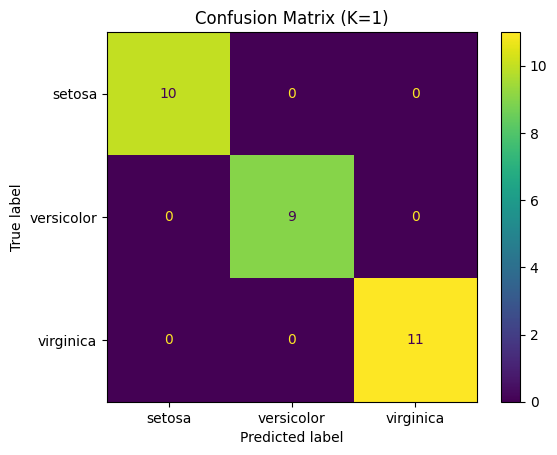

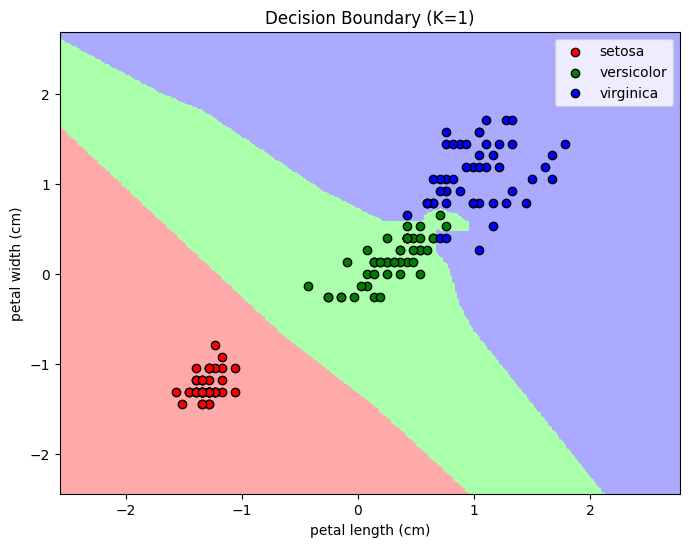

K = 3, Accuracy = 1.00


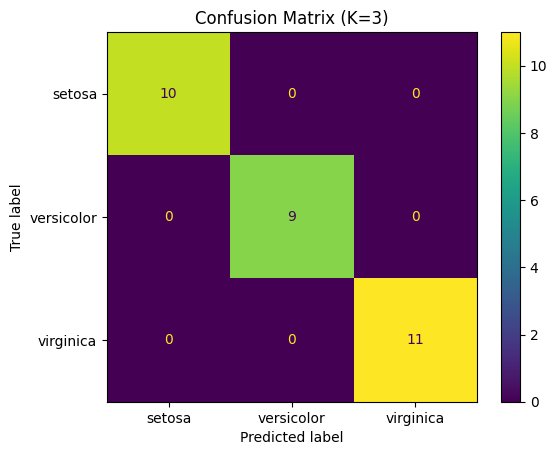

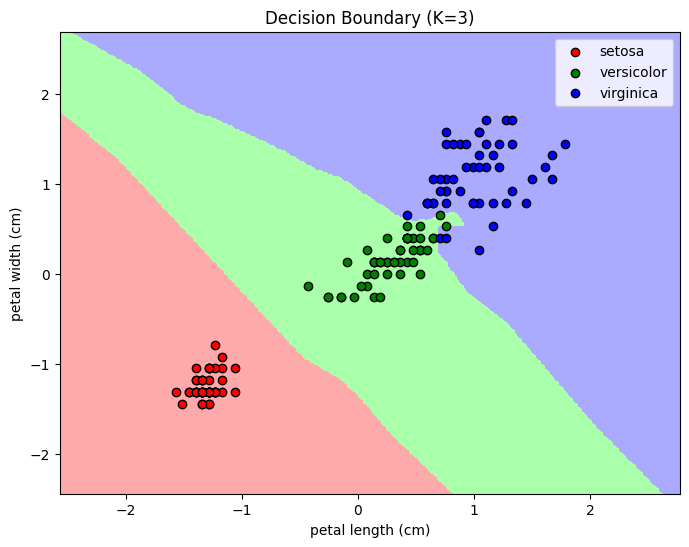

K = 5, Accuracy = 1.00


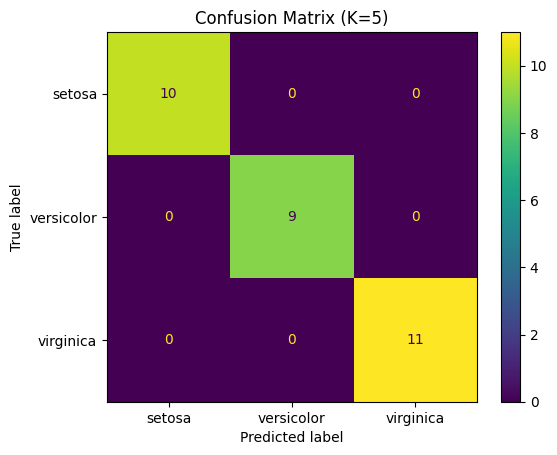

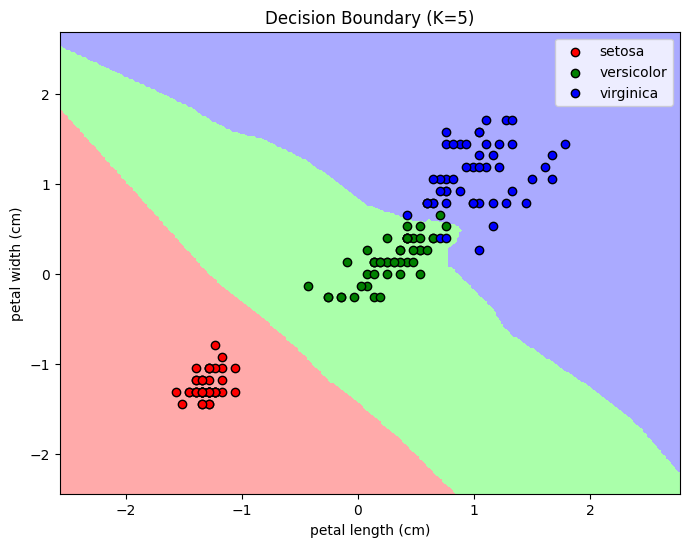

K = 7, Accuracy = 1.00


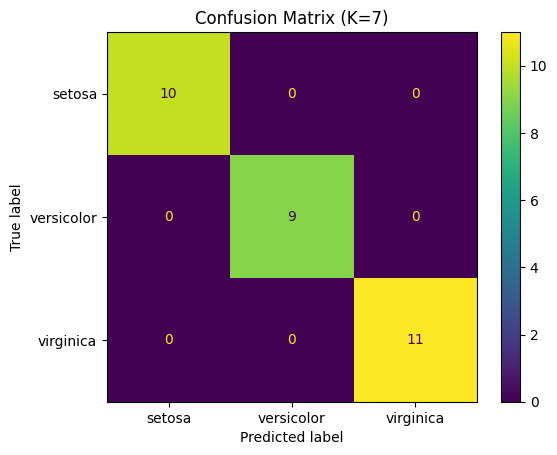

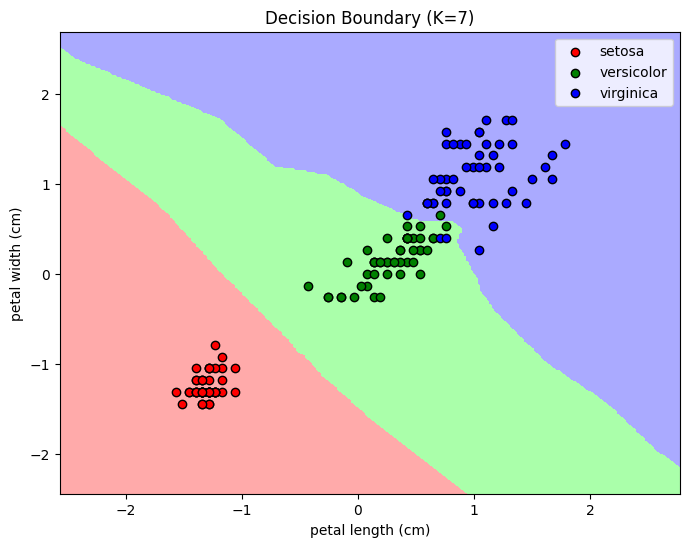

In [4]:
!pip install pandas
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris # Import load_iris

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Use actual column names from iris_df
features = ['petal length (cm)', 'petal width (cm)']  # Corrected feature names
X = iris_df[features].values
y = iris_df['Species'].astype('category').cat.codes  # Encode species labels numerically

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Experiment with different values of K
k_values = [1, 3, 5, 7]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k}, Accuracy = {acc:.2f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris_df['Species'].unique())
    disp.plot()
    plt.title(f"Confusion Matrix (K={k})")
    plt.show()

    # Plot decision boundaries
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(X_scaled[y == label, 0], X_scaled[y == label, 1], c=cmap_bold[idx], label=iris_df['Species'].unique()[idx], edgecolor='k')
    plt.title(f"Decision Boundary (K={k})")
    plt.xlabel(features[0]) # Update x-axis label
    plt.ylabel(features[1]) # Update y-axis label
    plt.legend()
    plt.show()